# Football Matches Statistics

## 1. Initial Exploration and Data Cleaning

The purpose of this notebook is to explore and clean the football dataset before performing the Exploratory Data Analysis (EDA).

This notebook follows the standard workflow:


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1.1 Load the dataset

In [3]:
df = pd.read_csv("dataset/football_matches_dataset.csv")

## 1.2. Initial Data Exploration

In [4]:
df.head()

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(16332, 55)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  str    
 2   away_team                                 16332 non-null  str    
 3   date                                      16332 non-null  str    
 4   league                                    16332 non-null  str    
 5   season                                    16332 non-null  str    
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                                  163

In [7]:
list(df.columns)

['Unnamed: 0',
 'home_team',
 'away_team',
 'date',
 'league',
 'season',
 'home_score',
 'away_score',
 'home_xg',
 'away_xg',
 'datetime',
 'home_standings',
 'away_standings',
 'home_points',
 'away_points',
 'home_points_last_4_matches',
 'away_points_last_4_matches',
 'home_points_last_2_home_matches',
 'away_points_last_2_away_matches',
 'home_goals_last_4_matches',
 'away_goals_last_4_matches',
 'home_goals_last_2_home_matches',
 'away_goals_last_2_away_matches',
 'home_goals_against_last_4_matches',
 'away_goals_against_last_4_matches',
 'home_goals_against_last_2_home_matches',
 'away_goals_against_last_2_away_matches',
 'home_mean_xg_last_4_matches',
 'away_mean_xg_last_4_matches',
 'home_mean_xg_last_2_home_matches',
 'away_mean_xg_last_2_away_matches',
 'home_mean_xg_against_last_4_matches',
 'away_mean_xg_against_last_4_matches',
 'home_mean_xg_against_last_2_home_matches',
 'away_mean_xg_against_last_2_away_matches',
 'home_formation',
 'away_formation',
 'home_defense_ra

In [8]:
[col for col in df.columns if "id" in col.lower()]

['home_midfield_rating',
 'away_midfield_rating',
 'home_midfield_rating_last_4_matches',
 'away_midfield_rating_last_4_matches',
 'home_midfield_rating_last_2_home_matches',
 'away_midfield_rating_last_2_away_matches']

In [9]:
df["Unnamed: 0"].head()

0    0
1    1
2    2
3    3
4    4
Name: Unnamed: 0, dtype: int64

In [10]:
df["Unnamed: 0"].duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Unnamed: 0,home_score,away_score,home_xg,away_xg,home_standings,away_standings,home_points,away_points,home_points_last_4_matches,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
count,16332.000000,16332.000000,16332.000000,16332.000000,16332.000000,16332.000000,16332.000000,16332.000000,16332.000000,16020.000000,...,16018.000000,16018.000000,16020.000000,16016.000000,16018.000000,16018.000000,16020.000000,16016.000000,16018.000000,16018.000000
mean,8165.500000,1.537595,1.213079,1.519489,1.198238,10.784778,10.647869,24.714487,24.902951,5.437765,...,6.850295,6.758092,6.876918,6.892891,6.967077,6.803555,6.936985,6.952650,7.040911,6.848876
std,4714.786634,1.310895,1.166409,0.898103,0.791728,5.592583,5.570980,17.915548,17.895257,2.938398,...,0.341491,0.352362,0.302985,0.304563,0.387721,0.372287,0.413593,0.415172,0.546994,0.506123
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,5.368333,5.333167,5.952500,5.925833,5.615000,5.570833,5.796250,5.857500,5.660000,5.545000
25%,4082.750000,1.000000,0.000000,0.850000,0.600000,6.000000,6.000000,10.000000,11.000000,3.000000,...,6.617000,6.524000,6.665625,6.681667,6.693333,6.542500,6.638750,6.660729,6.648333,6.480000
50%,8165.500000,1.000000,1.000000,1.360000,1.050000,11.000000,11.000000,22.000000,22.000000,5.000000,...,6.852750,6.754250,6.850000,6.866875,6.938125,6.776667,6.887500,6.901250,6.977500,6.777500
75%,12248.250000,2.000000,2.000000,2.030000,1.620000,16.000000,15.000000,36.000000,36.000000,7.000000,...,7.084833,7.000000,7.063333,7.078000,7.211667,7.027500,7.175417,7.189167,7.355625,7.146458
max,16331.000000,10.000000,9.000000,6.880000,6.500000,20.000000,20.000000,94.000000,97.000000,12.000000,...,8.156000,7.941000,8.335833,8.460000,8.675000,8.716250,9.293750,9.292500,9.650000,9.635000


In [12]:
df.describe(include="all")

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
count,16332.000000,16332,16332,16332,16332,16332,16332.000000,16332.000000,16332.000000,16332.000000,...,16018.000000,16018.000000,16020.000000,16016.000000,16018.000000,16018.000000,16020.000000,16016.000000,16018.000000,16018.000000
unique,NaN,157,157,1655,5,9,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Arsenal,Crystal Palace,December 22 2018,EPL,2014/2015,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,171,171,37,3420,1826,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8165.500000,NaN,NaN,NaN,NaN,NaN,1.537595,1.213079,1.519489,1.198238,...,6.850295,6.758092,6.876918,6.892891,6.967077,6.803555,6.936985,6.952650,7.040911,6.848876
std,4714.786634,NaN,NaN,NaN,NaN,NaN,1.310895,1.166409,0.898103,0.791728,...,0.341491,0.352362,0.302985,0.304563,0.387721,0.372287,0.413593,0.415172,0.546994,0.506123
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,5.368333,5.333167,5.952500,5.925833,5.615000,5.570833,5.796250,5.857500,5.660000,5.545000
25%,4082.750000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.850000,0.600000,...,6.617000,6.524000,6.665625,6.681667,6.693333,6.542500,6.638750,6.660729,6.648333,6.480000
50%,8165.500000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.360000,1.050000,...,6.852750,6.754250,6.850000,6.866875,6.938125,6.776667,6.887500,6.901250,6.977500,6.777500
75%,12248.250000,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,2.030000,1.620000,...,7.084833,7.000000,7.063333,7.078000,7.211667,7.027500,7.175417,7.189167,7.355625,7.146458


## 1.3. Missing Values

We checked for missing values to identify incomplete records and determine whether they should be removed, filled, or kept for further analysis.

In [13]:
df.isnull().sum()

Unnamed: 0                                    0
home_team                                     0
away_team                                     0
date                                          0
league                                        0
season                                        0
home_score                                    0
away_score                                    0
home_xg                                       0
away_xg                                       0
datetime                                      0
home_standings                                0
away_standings                                0
home_points                                   0
away_points                                   0
home_points_last_4_matches                  312
away_points_last_4_matches                  316
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_4_matches                   312
away_goals_last_4_matches               

In [14]:
df.isnull().sum().sort_values(ascending=False) #ordering in a DESC way

away_goals_last_4_matches                   316
away_points_last_4_matches                  316
away_midfield_rating_last_4_matches         316
away_defense_rating_last_4_matches          316
away_mean_xg_against_last_4_matches         316
away_mean_xg_last_4_matches                 316
away_goals_against_last_4_matches           316
away_attack_rating_last_4_matches           316
home_mean_xg_against_last_2_home_matches    314
home_goals_against_last_2_home_matches      314
home_defense_rating_last_2_home_matches     314
home_midfield_rating_last_2_home_matches    314
away_midfield_rating_last_2_away_matches    314
away_defense_rating_last_2_away_matches     314
away_mean_xg_against_last_2_away_matches    314
away_goals_against_last_2_away_matches      314
away_mean_xg_last_2_away_matches            314
home_mean_xg_last_2_home_matches            314
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_2_home_matches          

In [15]:
missing = df.isnull().sum()     #check

missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage.round(2)
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
away_goals_last_4_matches,316,1.93
away_points_last_4_matches,316,1.93
away_midfield_rating_last_4_matches,316,1.93
away_defense_rating_last_4_matches,316,1.93
away_mean_xg_against_last_4_matches,316,1.93
away_mean_xg_last_4_matches,316,1.93
away_goals_against_last_4_matches,316,1.93
away_attack_rating_last_4_matches,316,1.93
home_mean_xg_against_last_2_home_matches,314,1.92
home_goals_against_last_2_home_matches,314,1.92


Findings of isnull:

Several columns related to previous team performance contain missing values.

These missing values are expected because, at the beginning of each season, teams have not yet played enough matches to calculate previous statistics.

At this stage, no rows will be removed until we evaluate whether these missing values affect our research questions.

## 1.4. Duplicate Rows

We checked whether the dataset contains duplicated rows that could affect the analysis.

In [16]:
df.duplicated().sum()

np.int64(0)

Where not found any duplicated rows "0", so, no duplicate removal is required.

## 1.5. Index Column Review

The dataset contains an additional column called `Unnamed: 0`.

This column appears to be an automatically generated index from a previous CSV export rather than a meaningful identifier.

We verified that it contains unique values, but it will not be used in the analysis.

In [17]:
df["Unnamed: 0"].duplicated().sum()

np.int64(0)

This column will be removed during the data cleaning process because it does not provide analytical value.

## 1.6. Unique Values

We checked the number of unique values in each column to better understand which variables are categorical, numerical, or identifiers.

In [18]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values", ascending=False)

unique_values

,Unique Values
Unnamed: 0,16332
home_midfield_rating_last_4_matches,9917
away_midfield_rating_last_4_matches,9778
home_defense_rating_last_4_matches,8701
away_defense_rating_last_4_matches,8671
away_midfield_rating_last_2_away_matches,6856
home_midfield_rating_last_2_home_matches,6737
away_defense_rating_last_2_away_matches,6509
home_defense_rating_last_2_home_matches,6175
away_attack_rating_last_4_matches,6061


Findings of Unique Values

The unique values check helps identify categorical variables such as `league`, `season`, and team formations, as well as high-cardinality variables such as `home_team`, `away_team`, and `datetime`.

The `Unnamed: 0` column appears to be an automatically generated index from a previous CSV export and does not provide analytical value. Therefore, it will be removed during the data cleaning process.

## 1.7. Data Types

We reviewed the data types of each column to identify variables that may require conversion.

In [19]:
df.dtypes

Unnamed: 0                                    int64
home_team                                       str
away_team                                       str
date                                            str
league                                          str
season                                          str
home_score                                    int64
away_score                                    int64
home_xg                                     float64
away_xg                                     float64
datetime                                        str
home_standings                                int64
away_standings                                int64
home_points                                   int64
away_points                                   int64
home_points_last_4_matches                  float64
away_points_last_4_matches                  float64
home_points_last_2_home_matches             float64
away_points_last_2_away_matches             float64
home_goals_l

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  str    
 2   away_team                                 16332 non-null  str    
 3   date                                      16332 non-null  str    
 4   league                                    16332 non-null  str    
 5   season                                    16332 non-null  str    
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                                  163

Findings:

Most variables have the expected data types.

However, the `date` and `datetime` columns should be reviewed to determine which one will be used in the final dataset.

## 1.8. Check Invalid Values

In [21]:
(df["home_score"] < 0).sum()

np.int64(0)

In [22]:
(df["home_xg"] < 0).sum()

np.int64(0)

## 1.9. Check Categorical Values

Leagues

In [23]:
df["league"].value_counts()

league
EPL           3420
La liga       3420
Serie A       3420
Ligue 1       3318
Bundesliga    2754
Name: count, dtype: int64

Seasons

In [24]:
df["season"].value_counts()

season
2014/2015    1826
2015/2016    1826
2017/2018    1826
2018/2019    1826
2020/2021    1826
2021/2022    1826
2022/2023    1826
2016/2017    1825
2019/2020    1725
Name: count, dtype: int64

Formations

In [25]:
df["home_formation"].value_counts()

home_formation
0    8892
2    3561
3    2136
1    1740
4       3
Name: count, dtype: int64

## 1.10. Football-Specific Data Validation

Will check data which cannot be negative for the project

In [26]:
# Goals cannot be negative
(df["home_score"] < 0).sum()
(df["away_score"] < 0).sum()

np.int64(0)

In [27]:
# Expected Goals cannot be negative
(df["home_xg"] < 0).sum()
(df["away_xg"] < 0).sum()

np.int64(0)

In [28]:
# Current points should not be negative
(df["home_points"] < 0).sum()
(df["away_points"] < 0).sum()

np.int64(0)

## Quick Summary

In [29]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Unnamed: 0,int64,0,16332
home_team,str,0,157
away_team,str,0,157
date,str,0,1655
league,str,0,5
season,str,0,9
home_score,int64,0,11
away_score,int64,0,10
home_xg,float64,0,519
away_xg,float64,0,454


# 2. Initial Data Cleaning

### Planned Cleaning Actions

Based on the initial exploration, the following cleaning decisions will be applied:

- Remove the `Unnamed: 0` column because it is an exported index.
- Convert the `datetime` column to datetime format.
- Evaluate whether the `date` column is redundant.
- Keep missing values in previous-performance variables until we determine whether they affect our research questions.
- Create new engineered features for the analysis. (AS EXTRA)

## 2.1. Removing the "Unnamed: 0" column

In [30]:
clean_df = df.drop(columns=["Unnamed: 0"])

In [31]:
df.head()

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
clean_df.head()

,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,datetime,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,2014-08-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Creating a new DataFrame as **"clean_df"** to storage all our changes from de origina "df"

We passed from **"df"** with 55 columns, to **"clean_df"**(new ) with 54 columns.

## 2.2. Check and compare **"date"** and **"datetime"** columns

In [33]:
clean_df[["date", "datetime"]].head()

,date,datetime
0,August 08 2014,2014-08-08
1,August 09 2014,2014-08-09
2,August 09 2014,2014-08-09
3,August 09 2014,2014-08-09
4,August 09 2014,2014-08-09


In [34]:
clean_df[["date", "datetime"]].dtypes

date        str
datetime    str
dtype: object

In [35]:
clean_df["datetime"] = pd.to_datetime(clean_df["datetime"])

With this step we change the type od `datetime` to a real datetime64[ns]

In [36]:
clean_df[["date", "datetime"]].dtypes

date                   str
datetime    datetime64[us]
dtype: object

In [37]:
same_date = (clean_df["date"] == clean_df["datetime"].dt.strftime("%B %d %Y")) #.dt panda serie for dates, 
same_date.all()

np.True_

Both columns have the same dates


### Cleaning Decision

The dataset contains two columns representing the match date.

- `date` stores the date as a text string.
- `datetime` stores the same information in a format that can be converted into a proper datetime object.

At this stage, both columns will be kept until **THE TEAM** agrees on which one should be used in the final cleaned dataset.

NOTE: i will go by `datetime`, for better uses in the future, where we could access to years (["datetime"].dt.year), months (.dt.month), day (.dt.day_name())... 

# 3. Feature Engineering

In this section, we create new variables from the existing columns to support the analysis of our four research questions.

These new features will help us compare match results, goals, Expected Goals (xG), team form, points, ratings, and formations more clearly.

### 3.1. Match Result

To simplify the analysis, we created a new categorical variable called `match_result`.

Instead of comparing home and away goals repeatedly, this feature directly identifies whether the match ended in a Home Win, Draw, or Away Win.

This feature will be used throughout the EDA and SQL analysis, as it supports all four research questions.

In [38]:
clean_df.head(1) #exploring the table for getting the columns which will be needed

,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,datetime,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,2014-08-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
conditions = [
    clean_df["home_score"] > clean_df["away_score"],
    clean_df["home_score"] < clean_df["away_score"]
]

choices = [
    "Home Win",
    "Away Win"
]

clean_df["match_result"] = np.select(
    conditions,
    choices,
    default="Draw"
)


Why `np.select()`?

This feature could also be created using a `for` loop, which was my first approach.

However, I decided to use `np.select()` because it applies the conditions to the entire DataFrame at once (vectorized operations), making the code more efficient and more consistent with pandas best practices.

The variables `conditions` and `choices` are not reserved keywords. They are simply descriptive variable names chosen to improve readability. They could be renamed if needed.

The only reserved parameter in this function call is `default`, which defines the value assigned when none of the specified conditions are met.

In [40]:
clean_df["match_result"].value_counts()

match_result
Home Win    7270
Away Win    4975
Draw        4087
Name: count, dtype: int64

In [41]:
clean_df[["home_score", "away_score", "match_result"]].head(10)

,home_score,away_score,match_result
0,2,2,Draw
1,0,3,Away Win
2,0,2,Away Win
3,0,0,Draw
4,0,1,Away Win
5,1,0,Home Win
6,3,2,Home Win
7,3,3,Draw
8,2,0,Home Win
9,1,2,Away Win


Findings

The `match_result` feature was successfully created.

The distribution of results shows that Home Wins are the most frequent outcome, followed by Away Wins and Draws. This distribution is consistent with the well-known home advantage observed in professional football.

### 3.2. Goal Difference

In [42]:
clean_df["goal_difference"] = clean_df["home_score"] - clean_df["away_score"]

In [43]:
clean_df[["home_score", "away_score", "goal_difference"]].head(5)

,home_score,away_score,goal_difference
0,2,2,0
1,0,3,-3
2,0,2,-2
3,0,0,0
4,0,1,-1


Findings

The `goal_difference` feature was successfully created and validated.

Positive values represent home victories, negative values represent away victories, and zero represents draws.

The observed range (-9 to 9) appears realistic for professional football matches, indicating that the feature has been calculated correctly.

Now created `goal_difference` let test some statistics

In [44]:
clean_df["goal_difference"].describe() 

count    16332.000000
mean         0.324516
std          1.831458
min         -9.000000
25%         -1.000000
50%          0.000000
75%          1.000000
max          9.000000
Name: goal_difference, dtype: float64

Some conclusions:

MIN 
Show that largest AWAY victory was by **-9** goals of difference (cause it is negative number)

MAX 
Show that largest HOME victory was by **9** goals of difference (cause it is positive number)

MEDIAN
Value is **0**, meaning that the center of the distribution is a goal difference of zero.
This suggests that most matches are relatively balanced, with many ending in draws or being decided by a small goal margin.

### 3.4. Total Goals

In [45]:
# Create total_goals
clean_df["total_goals"] = clean_df["home_score"] + clean_df["away_score"]

In [46]:
clean_df[["home_score", "away_score", "total_goals"]].head()

,home_score,away_score,total_goals
0,2,2,4
1,0,3,3
2,0,2,2
3,0,0,0
4,0,1,1


The `total_goals` feature represents the total number of goals scored in each match.

### 3.5. Total Expected Goals

In [47]:
# Create total_xg
clean_df["total_xg"] = clean_df["home_xg"] + clean_df["away_xg"]

In [48]:
clean_df[["home_xg", "away_xg", "total_xg"]].head()

,home_xg,away_xg,total_xg
0,1.37,2.66,4.03
1,0.81,1.24,2.05
2,0.63,1.50,2.13
3,1.54,0.06,1.60
4,1.02,0.75,1.77


In [49]:
clean_df[["total_goals","total_xg"]].describe()

,total_goals,total_xg
count,16332.000000,16332.000000
mean,2.750674,2.717727
std,1.674416,1.068064
min,0.000000,0.150000
25%,2.000000,1.930000
50%,3.000000,2.610000
75%,4.000000,3.370000
max,12.000000,8.200000


The `total_xg` feature represents the combined expected goals generated by both teams.

Both features were successfully validated and will support analyses related to attacking performance and scoring efficiency.

### 3.6. Expected Goal Difference

In [50]:
clean_df["xg_difference"] = clean_df["home_xg"] - clean_df["away_xg"]

In [51]:
clean_df[["home_xg", "away_xg", "xg_difference"]].head()

,home_xg,away_xg,xg_difference
0,1.37,2.66,-1.29
1,0.81,1.24,-0.43
2,0.63,1.50,-0.87
3,1.54,0.06,1.48
4,1.02,0.75,0.27


The `xg_difference` feature compares the expected goals generated by both teams before each match.

Positive values indicate that the home team generated more expected goals, while negative values indicate that the away team generated more expected goals.

This feature will help evaluate whether a higher expected goal difference is associated with better match performance.

In [52]:
clean_df[["xg_difference"]].describe()

,xg_difference
count,16332.000000
mean,0.321250
std,1.313804
min,-5.760000
25%,-0.500000
50%,0.300000
75%,1.130000
max,6.290000


### 3.7. Point Difference

The ``points_difference`` feature compares the league points accumulated by both teams before the match.

Positive values indicate that the home team entered the match with more league points, while negative values indicate that the away team had more points.

This feature will help evaluate whether teams with a stronger league position tend to achieve better match performance.

In [53]:
clean_df["points_difference"] = clean_df["home_points"] - clean_df["away_points"] 

In [54]:
clean_df[["home_points", "away_points", "points_difference"]].tail()

,home_points,away_points,points_difference
16327,68,49,19
16328,39,41,-2
16329,60,31,29
16330,46,69,-23
16331,63,76,-13


In [55]:
clean_df[["points_difference"]].describe()

,points_difference
count,16332.000000
mean,-0.188464
std,14.338307
min,-66.000000
25%,-7.000000
50%,0.000000
75%,6.000000
max,74.000000


Findings

The descriptive statistics indicate that the feature was calculated correctly.

Positive values indicate matches where the home team generated more expected goals, while negative values indicate higher expected goals for the away team.

This feature will support analyses comparing expected performance with actual match outcomes.

### 3.8.1 Recent Form Difference

In [56]:
#newcol = (
 #   clean_df.home_points_last_4_matches
  #  +
   # clean_df.away_points_last_4_matches
#)

reviewing this feature, noticed that the first approach stored the result in `newcol` by **adding** the recent points of both teams:

newcol = (
    clean_df.home_points_last_4_matches +
    clean_df.away_points_last_4_matches
)

even with this calculation is mathematically correct, it represents the **combined recent points of both teams**, rather than comparing which team was in better form before the match.

the question objective is to analyse **recent team form**, and comparing the two teams is more meaningful than summing their points.

For this reason, we decided to calculate the feature as the difference between the home and away teams' recent points:


clean_df["recent_form_difference"] = (clean_df["home_points_last_4_matches"] - clean_df["away_points_last_4_matches"])


this version is easier to interpret:

- Positive values indicate that the home team entered the match in better recent form.
- Negative values indicate that the away team entered the match in better recent form.
- Values close to zero indicate that both teams had a similar recent performance.

I believe this is more close to our research question:

> **Does recent team form influence match outcomes?**

### 3.8.2 Recent Form Difference

The `recent_form_difference` feature compares the recent performance of both teams based on the total number of points earned in their previous four matches.

Positive values indicate that the home team entered the match in better recent form, while negative values indicate that the away team had better recent form.

This feature will help evaluate whether recent team form influences match outcomes.

In [57]:
clean_df["recent_form_difference"] = (clean_df["home_points_last_4_matches"] - clean_df["away_points_last_4_matches"])

In [58]:
clean_df[["home_points_last_4_matches", "away_points_last_4_matches", "recent_form_difference"]].tail()

,home_points_last_4_matches,away_points_last_4_matches,recent_form_difference
16327,7.0,5.0,2.0
16328,4.0,7.0,-3.0
16329,2.0,4.0,-2.0
16330,3.0,6.0,-3.0
16331,9.0,7.0,2.0


In [59]:
clean_df[["recent_form_difference"]].describe()

,recent_form_difference
count,15903.000000
mean,-0.155379
std,4.096612
min,-12.000000
25%,-3.000000
50%,0.000000
75%,3.000000
max,12.000000


Findings

The `recent_form_difference` feature was successfully created by comparing the total points earned by both teams in their previous four matches.

Positive values indicate that the home team entered the match with better recent form, while negative values indicate better recent form for the away team.

Some missing values are expected because teams have not yet played four matches at the beginning of each season.

This feature will support Research Question 2 by allowing us to investigate whether teams in better recent form are more likely to achieve better match results.

In [60]:
clean_df["recent_form_difference"].isna().sum()

np.int64(429)

Missing values are expected because, during the first matches of each season, teams have not yet played four previous matches. Therefore, recent form cannot be calculated for those observations.

### 3.9. Average Team Rating and Rating Difference

As we need TEAM players ratings and not individual ratings, for comparing between teams, we are calculating each TEAM (home and away) ratings and calculating the difference between them, in that case the positive rating will show a better rating for Home team and negative rating will show better rating for away team

`average_team_rating`

Our research question focuses on **team player ratings**, not individual player ratings.

To compare both teams fairly, we calculate the average rating of the home team and the away team using their defense, midfield, and attack ratings.

Finally, we create a new feature called `rating_difference`.

- A **positive** value indicates that the home team has a higher average rating.
- A **negative** value indicates that the away team has a higher average rating.
- A value close to **zero** indicates that both teams have similar overall ratings.

In [61]:
clean_df["average_home_team_rating"] = clean_df[["home_attack_rating", "home_midfield_rating", "home_defense_rating"]].mean(axis=1) #axis 0 columns, 1 rows

In [62]:
clean_df["average_away_team_rating"] = clean_df[["away_attack_rating", "away_midfield_rating", "away_defense_rating"]].mean(axis=1) #axis 0 columns, 1 rows

In [63]:
clean_df["rating_difference"] = clean_df["average_home_team_rating"] - clean_df["average_away_team_rating"]

In [64]:
clean_df[["average_home_team_rating", "average_away_team_rating", "rating_difference"]].head(5)

,average_home_team_rating,average_away_team_rating,rating_difference
0,6.862000,7.026667,-0.164667
1,6.278056,7.997333,-1.719278
2,6.246833,7.390222,-1.143389
3,6.810889,6.705333,0.105556
4,6.654667,7.151333,-0.496667


In [65]:
clean_df[["average_home_team_rating","average_away_team_rating","rating_difference"]].describe()

,average_home_team_rating,average_away_team_rating,rating_difference
count,16332.000000,16332.000000,16332.000000
mean,6.950670,6.800973,0.149697
std,0.459847,0.446564,0.847919
min,5.371111,5.366000,-3.450000
25%,6.629292,6.488264,-0.411736
50%,6.916750,6.770333,0.139694
75%,7.242056,7.081583,0.715208
max,8.880000,9.103333,3.415611


Findings

The average team ratings were successfully calculated using the defense, midfield, and attack ratings.

The new `rating_difference` feature compares the overall quality of both teams before each match.

Positive values indicate a stronger home team, negative values indicate a stronger away team, while values close to zero suggest both teams have similar overall ratings.

This feature will support Research Question 4 by allowing us to investigate whether stronger team ratings are associated with better match performance.

clean_df.to_csv("cleaned_data.csv", index=False)

In [66]:
clean_df.to_csv("cleaned_football_data.csv", index=False)

In [67]:
cleaned_df = pd.read_csv("cleaned_football_data.csv")

cleaned_df.shape

(16332, 64)

In [68]:
clean_df.shape

(16332, 64)

In [69]:
cleaned_df.head()

,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,datetime,...,match_result,goal_difference,total_goals,total_xg,xg_difference,points_difference,recent_form_difference,average_home_team_rating,average_away_team_rating,rating_difference
0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,2014-08-08,...,Draw,0,4,4.03,-1.29,0,NaN,6.862000,7.026667,-0.164667
1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,2014-08-09,...,Away Win,-3,3,2.05,-0.43,0,NaN,6.278056,7.997333,-1.719278
2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,2014-08-09,...,Away Win,-2,2,2.13,-0.87,0,NaN,6.246833,7.390222,-1.143389
3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,2014-08-09,...,Draw,0,0,1.60,1.48,0,NaN,6.810889,6.705333,0.105556
4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,2014-08-09,...,Away Win,-1,1,1.77,0.27,0,NaN,6.654667,7.151333,-0.496667


# <span style="color:gold">Research Questions</span>

## 1. How accurately do Expected Goals (xG) predict the final match result?

@Berni

## 2. Does recent team performance influence match outcomes?

more Univariate Analysis

16332 rows - games from european leagues (bl, La Liga etc) Q3 2014 - Q2 2023 

* Relevant variables:

(from kaggle.com description of dataset)
- 11-12 - current standings (table positions) home/away team just before the start of the match
- (not 15-16 - total number of points home/away team have gained in their previous 4 matches)
- 19-20 - total number of goals home/away team have scored in their previous 4 matches 
- 23-24 - total number of goals home/away team have conceded (goals against) in their previous 4 matches
- (27-30 - average value of xG home/away team have gained in their previous 4 matches)

(each) - can be NaN in case of the first matches of the season when teams have not played enough matches this season yet

In [70]:
"""
#bins for home_score - optional
import seaborn as sns
plt.figure(figsize=(8,6))
sns.histplot(
    data=clean_df,
    x='home_score',
    #hue='match_result',
    bins=20,
    palette={'Home Win':'skyblue','Draw':'lightgreen','Away Win':'salmon'},
    multiple='stack',
    edgecolor='black'
)
plt.xlabel('Home Goals')
plt.ylabel('Count')
plt.title('Distribution of Home Goals')
plt.tight_layout()


"""
clean_df["home_score"].value_counts()
clean_df["away_score"].value_counts()

away_score
1    5745
0    5138
2    3304
3    1415
4     519
5     151
6      44
7      11
8       3
9       2
Name: count, dtype: int64

In [71]:
#clean_df['goal_difference'].value_counts().plot(kind='bar', color=['coral', 'gold'], edgecolor='white')

In [72]:
clean_df["match_result"].value_counts()

total_matches = clean_df.shape[0]

clean_df["match_result"].value_counts()['Home Win'] / total_matches, clean_df["match_result"].value_counts()['Draw'] / total_matches, clean_df["match_result"].value_counts()['Away Win'] / total_matches

(np.float64(0.44513837864315453),
 np.float64(0.25024491795248593),
 np.float64(0.30461670340435953))

The Propability of winning is 0.45 for Home Team.

The Probability of winning is 0.25 for Away Team.

The Probability of a Draw is 0.3.

In [73]:
import numpy as np

# Definiere die Bedingungen
conditions = [
    clean_df["recent_form_difference"] > 0,
    clean_df["recent_form_difference"] < 0,
    clean_df["recent_form_difference"] == 0
]

# Definiere die dazugehörigen Ausgaben
choices = ["Home Win", "Away Win", "Draw"]

# Wende np.select an, um die neue Spalte zu erstellen
clean_df["recent_form_difference_ten"] = np.select(conditions, choices, default="")

# Kurze Kontrolle, ob es geklappt hat:
print(clean_df[["recent_form_difference", "recent_form_difference_ten"]].tail())

       recent_form_difference recent_form_difference_ten
16327                     2.0                   Home Win
16328                    -3.0                   Away Win
16329                    -2.0                   Away Win
16330                    -3.0                   Away Win
16331                     2.0                   Home Win


In [74]:
pd.crosstab(clean_df["recent_form_difference_ten"] ,clean_df["match_result"] )

match_result,Away Win,Draw,Home Win
recent_form_difference_ten,,,
,140,130,159
Away Win,2872,1895,2653
Draw,471,410,739
Home Win,1492,1652,3719


The recent form predicts 

a Home Win with certainty

3719 / (1492 + 1652 + 3719) = 0.54 <span style="color:red">!</span>  #not bad

an Away Win with certainty

2872 / (2872+ 1895 + 2653) = 0.38

and a Draw with certainty

410 / (471 + 410 + 739) = 0.25

vs. Propabilitys in dataset:

The Propability of winning is <span style="color:red">0.45</span> for Home Team.

The Probability of winning is 0.25 for Away Team.

The Probability of a Draw is 0.3.

nb: agent's opinion:
RQ2 (Recent Form vs Outcome): Showed a clear increase in home win probability (54.19% vs <span style="color:orange">35.75%</span>) when the home team is in better recent form.

# 3. Do teams with more current points consistently achieve better match results?

Objective: Investigate whether teams with a higher number of league points before a match are
more likely to obtain better match results. 
Expected Goals (xG) will be used as a supporting variable rather than the main explanatory variable

## Initial Hypothesis

We expect teams with more league points before a match to achieve better match results more frequently.

However, football is unpredictable, therefore we also expect to find matches where teams with fewer points still achieve positive results.

Expected Goals (xG) will be analysed as a supporting metric to determine whether it reinforces or contradicts the relationship between current points and match outcomes.

## Variables Used

To answer this research question, we will use both original dataset variables and engineered features.

### Primary variables
- home_points
- away_points
- points_difference
- match_result

These variables directly measure the teams' league performance before each match.

### Supporting variables
- home_xg
- away_xg
- xg_difference
- goal_difference
- league
- season

These variables provide additional context by comparing expected performance, actual goal difference and possible differences across leagues and seasons.

In [ ]:
clean_df.home_points.head()


0    0
1    0
2    0
3    0
4    0
Name: home_points, dtype: int64

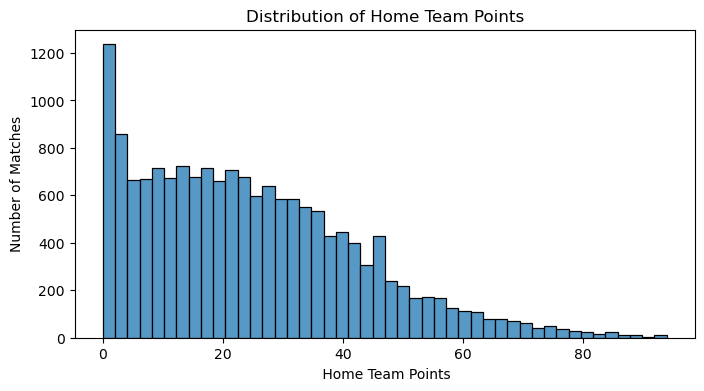

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(data=clean_df, x= "home_points")
plt.title("Distribution of Home Team Points")
plt.xlabel(" Home Team Points")
plt.ylabel("Number of Matches")
plt.show()


The distribution shows that home teams cover the full range of league standings, although most matches involve teams with relatively low or medium point totals. Several outliers represent teams with exceptionally high league points.

In [ ]:
clean_df.away_points.head()

0    0
1    0
2    0
3    0
4    0
Name: away_points, dtype: int64

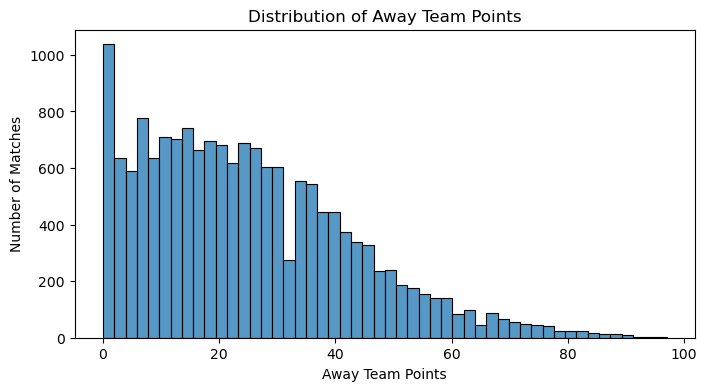

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=clean_df, x= "away_points")
plt.title("Distribution of Away Team Points")
plt.xlabel("Away Team Points")
plt.ylabel("Number of Matches")
plt.show()

In [ ]:
clean_df.points_difference.head()

0    0
1    0
2    0
3    0
4    0
Name: points_difference, dtype: int64

Home and Away points present some similiar distribution.

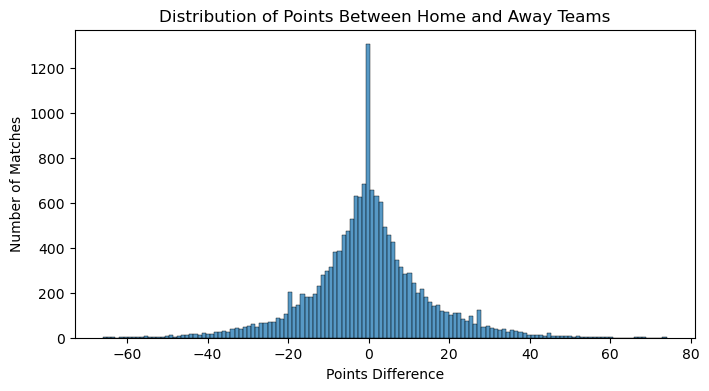

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=clean_df, x="points_difference")
plt.title("Distribution of Points Between Home and Away Teams")
plt.xlabel("Points Difference")
plt.ylabel("Number of Matches")
plt.show()

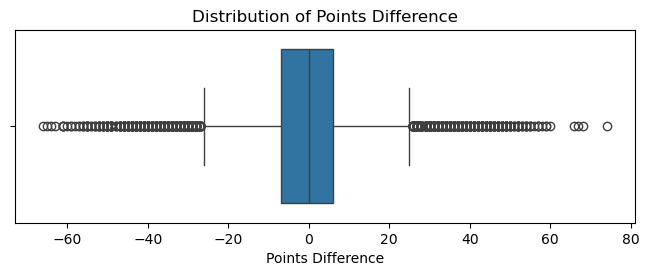

In [ ]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(data=clean_df, x="points_difference")
plt.title("Distribution of Points Difference")
plt.xlabel("Points Difference")
plt.show()

In [ ]:
clean_df.points_difference.describe()

count    16332.000000
mean        -0.188464
std         14.338307
min        -66.000000
25%         -7.000000
50%          0.000000
75%          6.000000
max         74.000000
Name: points_difference, dtype: float64

We expected the distribution to be centered around zero because many matches involve teams with similar league standings, while large point differences should be less frequent.

The distribution of points_difference is centered around zero, suggesting that many matches involve teams with similar league standings.

Both positive and negative tails indicate that some matches are played between teams with very different numbers of accumulated points.

The boxplot confirms that most matches involve teams with relatively small differences in league points.

Several outliers appear on both sides of the distribution, representing matches between teams with very different league standings.

These outliers are expected in football competitions and correspond to real competitive differences rather than data quality issues.

### Points Diferrence (numerical) VS Match Result (categorical)

 Relationship Between Points Difference and Match Result

This analysis evaluates whether differences in league points before a match are associated with the final match outcome.

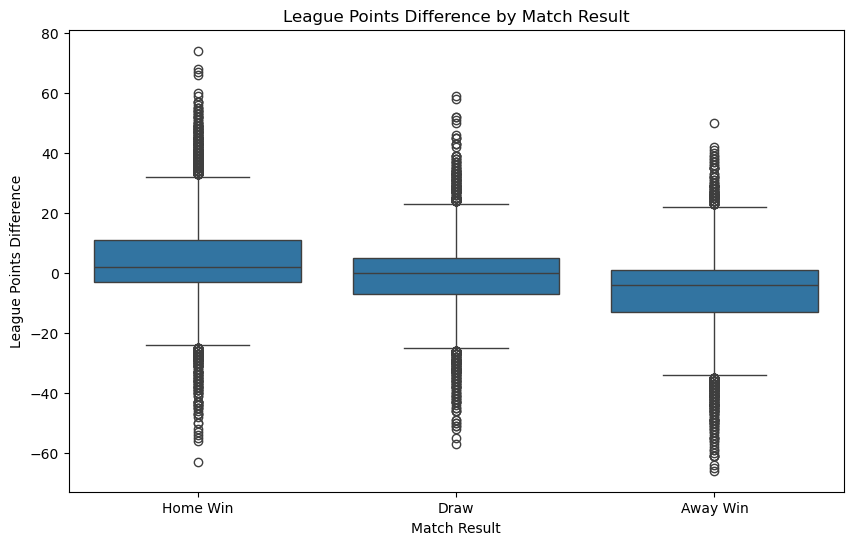

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=clean_df, x="match_result", y="points_difference", order=["Home Win", "Draw", "Away Win"])
plt.title("League Points Difference by Match Result")
plt.xlabel("Match Result")
plt.ylabel("League Points Difference")
plt.show()

In [ ]:
clean_df.groupby("match_result")["points_difference"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
match_result,,,,,,,,
Away Win,4975.0,-6.24,13.77,-66.0,-13.0,-4.0,1.0,50.0
Draw,4087.0,-0.90,12.50,-57.0,-7.0,0.0,5.0,59.0
Home Win,7270.0,4.35,14.08,-63.0,-3.0,2.0,11.0,74.0


Home victories generally occur when the home team has a positive league points advantage.

Away victories are more common when the away team has accumulated more league points.

Draws tend to occur between teams with relatively similar league standings.

Although many outliers exist, the overall pattern suggests that current league points are associated with match outcomes.

### Points Difference vs Goal Difference

Relationship Between League Points Difference and Goal Difference

Teams with more league points also tend to generate higher expected goals.

This suggests that stronger teams not only collect more points but also create better scoring opportunities.

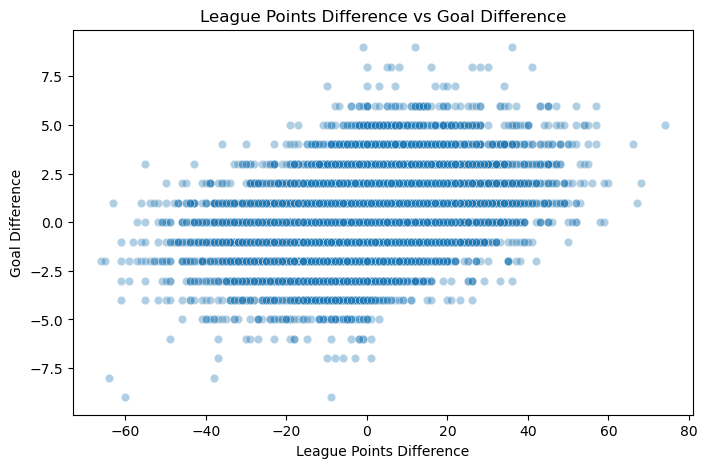

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=clean_df, x="points_difference", y="goal_difference",alpha=0.35)
plt.title("League Points Difference vs Goal Difference")
plt.xlabel("League Points Difference")
plt.ylabel("Goal Difference")
plt.show()

In [ ]:
clean_df[["points_difference","goal_difference"]].corr()

,points_difference,goal_difference
points_difference,1.000000,0.362194
goal_difference,0.362194,1.000000


A positive relationship is observed between league points difference and goal difference.

Teams with larger advantages in league points generally achieve larger winning margins, although considerable variability remains.

### Points Difference vs Expected Goals Difference

Points Difference vs Expected Goals Difference

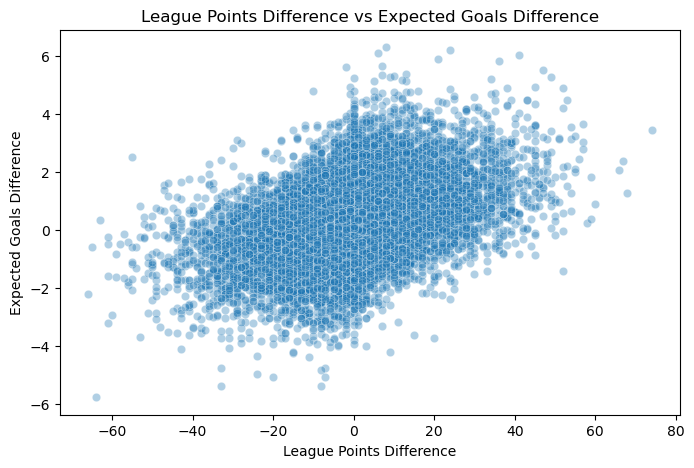

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=clean_df, x="points_difference", y="xg_difference", alpha=0.35)
plt.title("League Points Difference vs Expected Goals Difference")
plt.xlabel("League Points Difference")
plt.ylabel("Expected Goals Difference")
plt.show()

In [ ]:
clean_df[["points_difference","xg_difference"]].corr()

,points_difference,xg_difference
points_difference,1.000000,0.419882
xg_difference,0.419882,1.000000


### SQL Analasys Validation

To validate the findings obtained during the exploratory data analysis in Pandas, we perform several SQL queries on the original database.

These queries allow us to confirm whether the observed relationships remain consistent when analysed directly from the relational database.

In [ ]:
import sqlite3
conn = sqlite3.connect("football_project.db")
clean_df.to_sql("cleaned_matches", conn, if_exists="replace", index=False)

16332

 SQL Analysis 1

Average league points difference by match result.

In [ ]:
query = """
SELECT
    match_result,
    ROUND(AVG(points_difference),2) AS avg_points_difference
FROM cleaned_matches
GROUP BY match_result;
"""

pd.read_sql(query, conn)

,match_result,avg_points_difference
0,Away Win,-6.24
1,Draw,-0.90
2,Home Win,4.35


The SQL results confirm the trend observed during the EDA.

Matches won by the home team generally present positive league point differences, while away victories are associated with negative point differences.

SQL Analysis 2

Average league points difference by league.

In [ ]:
query = """
SELECT
    league,
    ROUND(AVG(points_difference),2) AS avg_points_difference
FROM cleaned_matches
GROUP BY league;
"""

pd.read_sql(query, conn)

,league,avg_points_difference
0,Bundesliga,-0.20
1,EPL,-0.15
2,La liga,-0.22
3,Ligue 1,-0.23
4,Serie A,-0.14


findings?

SQL Analysis 3

Average league points difference by season.

In [ ]:
query = """
SELECT
    season,
    ROUND(AVG(points_difference),2) AS avg_points_difference
FROM cleaned_matches
GROUP BY season
ORDER BY season;
"""

pd.read_sql(query, conn)

,season,avg_points_difference
0,2014/2015,-0.23
1,2015/2016,-0.16
2,2016/2017,-0.33
3,2017/2018,-0.20
4,2018/2019,-0.28
5,2019/2020,-0.18
6,2020/2021,-0.06
7,2021/2022,-0.15
8,2022/2023,-0.11


### Aditional Tables

Estatistics By League

In [ ]:
clean_df.groupby("league")["points_difference"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
league,,,,,,,,
Bundesliga,2754.0,-0.20,12.51,-59.0,-7.0,0.0,6.0,60.0
EPL,3420.0,-0.15,15.25,-61.0,-8.0,0.0,7.0,74.0
La liga,3420.0,-0.22,14.40,-64.0,-7.0,0.0,7.0,59.0
Ligue 1,3318.0,-0.23,13.21,-60.0,-6.0,0.0,5.0,57.0
Serie A,3420.0,-0.14,15.70,-66.0,-8.0,0.0,7.0,68.0


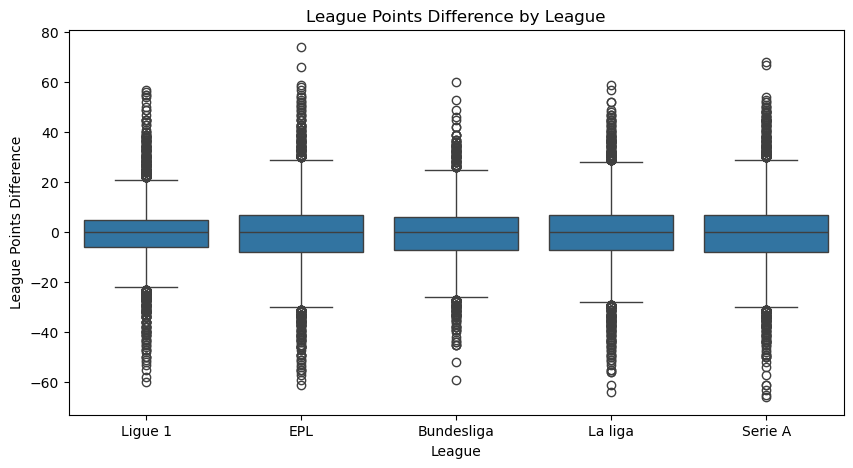

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=clean_df, x="league", y="points_difference")
plt.title("League Points Difference by League")
plt.xlabel("League")
plt.ylabel("League Points Difference")
plt.show()

Estatistics By Seasons

In [ ]:
clean_df.groupby("season")["points_difference"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2014/2015,1826.0,-0.23,13.47,-64.0,-7.0,0.0,6.0,59.0
2015/2016,1826.0,-0.16,13.59,-63.0,-6.0,0.0,6.0,60.0
2016/2017,1825.0,-0.33,15.15,-66.0,-7.0,0.0,6.0,66.0
2017/2018,1826.0,-0.20,15.36,-65.0,-7.0,0.0,7.0,67.0
2018/2019,1826.0,-0.28,14.78,-59.0,-7.0,0.0,7.0,74.0
2019/2020,1725.0,-0.18,13.27,-55.0,-6.0,0.0,6.0,59.0
2020/2021,1826.0,-0.06,14.19,-61.0,-7.0,0.0,7.0,49.0
2021/2022,1826.0,-0.15,14.12,-49.0,-7.0,0.0,7.0,55.0
2022/2023,1826.0,-0.11,14.92,-58.0,-8.0,0.0,7.0,68.0


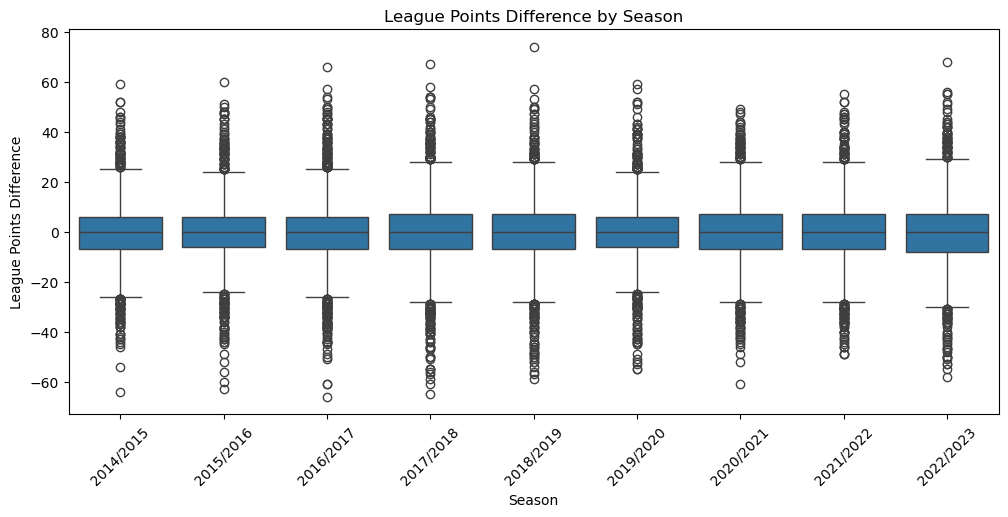

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=clean_df, x="season", y="points_difference")
plt.title("League Points Difference by Season")
plt.xlabel("Season")
plt.ylabel("League Points Difference")
plt.xticks(rotation=45)
plt.show()

### Findings

Teams with higher league points before a match generally achieve better match results.

Positive league points differences are associated with home victories, while negative differences are more common in away victories.

Teams with larger league point advantages also tend to produce higher goal differences and higher Expected Goals (xG).

However, football remains unpredictable, as numerous exceptions and outliers demonstrate that league points alone cannot fully explain match outcomes.

## Conclusion

The analysis suggests that current league points are a useful indicator of future match performance.

Although league points do not perfectly predict results, teams with higher accumulated points generally obtain better outcomes and generate stronger performances.

Therefore, current league points can be considered an informative predictor of match performance, especially when combined with complementary variables such as Expected Goals (xG).

## 4. How do team player ratings and team formations influence match performance?

We analyze whether higher-rated teams outperform lower-rated ones, and which formations are associated with the best attacking output

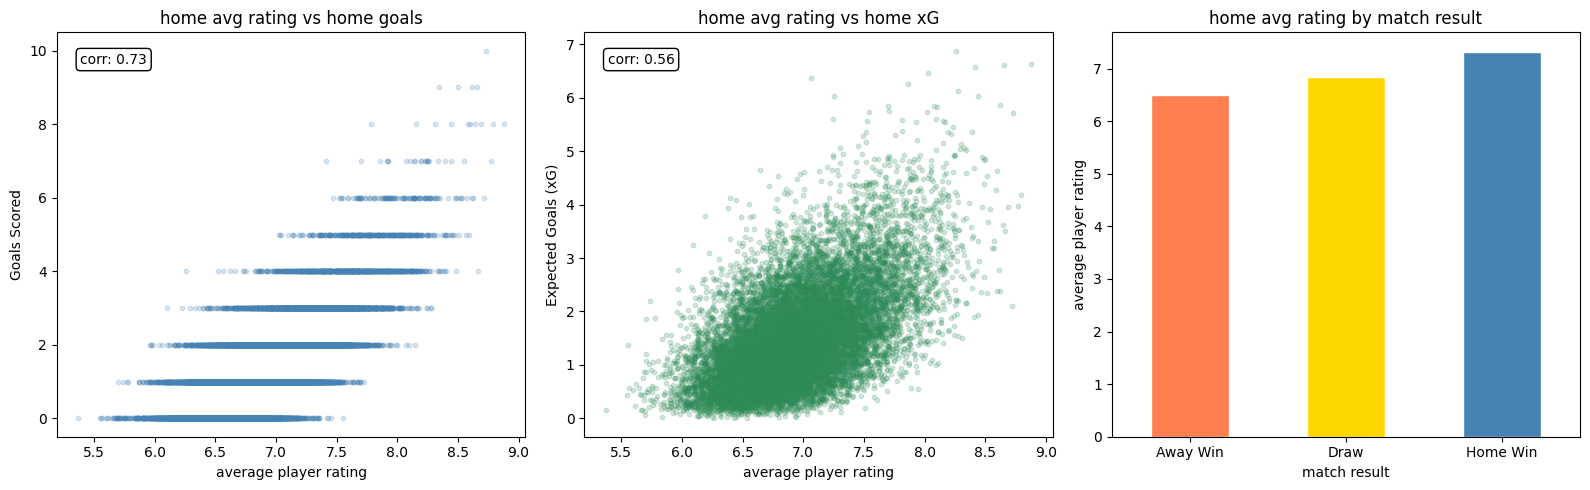

Rating vs Goals correlation 0.730
Rating vs xG correlation 0.563

 Conclusion: Higher-rated teams tend to score more goals and generate more xG,
   but the correlation is modest. Football has high variance!


In [75]:
clean_df['home_avg_rating'] = clean_df[['home_defense_rating', 'home_midfield_rating', 'home_attack_rating']].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(clean_df['home_avg_rating'], clean_df['home_score'], alpha=0.2, c='steelblue', s=10)
axes[0].set_title('home avg rating vs home goals')
axes[0].set_xlabel('average player rating')
axes[0].set_ylabel('Goals Scored')
corr_rating_goals = clean_df['home_avg_rating'].corr(clean_df['home_score'])
axes[0].text(0.05, 0.95, f'corr: {corr_rating_goals:.2f}', transform=axes[0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

axes[1].scatter(clean_df['home_avg_rating'], clean_df['home_xg'], alpha=0.2, c='seagreen', s=10)
axes[1].set_title('home avg rating vs home xG')
axes[1].set_xlabel('average player rating')
axes[1].set_ylabel('Expected Goals (xG)')
corr_rating_xg = clean_df['home_avg_rating'].corr(clean_df['home_xg'])
axes[1].text(0.05, 0.95, f'corr: {corr_rating_xg:.2f}', transform=axes[1].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

clean_df.groupby('match_result')['home_avg_rating'].mean().reindex(['Away Win', 'Draw', 'Home Win']).plot(kind='bar', ax=axes[2], color=['coral', 'gold', 'steelblue'], edgecolor='white')
axes[2].set_title('home avg rating by match result')
axes[2].set_xlabel('match result')
axes[2].set_ylabel('average player rating')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Rating vs Goals correlation {corr_rating_goals:.3f}")
print(f"Rating vs xG correlation {corr_rating_xg:.3f}")
print("\n Conclusion: Higher-rated teams tend to score more goals and generate more xG,")
print("   but the correlation is modest. Football has high variance!")

How do ratings & formations influence performance? **Strong correlation!** Home average rating correlates 0.73 with goals scored and 0.56 with xG. 